# 1. Project Title
## CUSTOMER CHURN PREDICTION & INTELLIGENCE SYSTEM

# 2. Problem Statement
Customer churn is a major problem for telecom, subscription, SaaS, banking, and service-based companies. Companies want to identify customers who are likely to leave their service before they actually churn.
This project builds a machine learning system that predicts whether a customer is likely to churn based on demographics, service usage, contract information, and billing information.

# 3. Business Objective
- Identify high-risk customers before they churn.
- Provide actionable insights into why they might churn.
- Enable businesses to take targeted retention actions.
- Note: The system predicts *risk* based on historical data and does not guarantee that a customer will definitely churn.

# 4. Dataset Source
Using the IBM Telco Customer Churn dataset.
Source: https://github.com/IBM/telco-customer-churn-on-icp4d

# 5. Dataset Description
- Target Variable: `Churn` (Yes / No)
- Features: Demographics (gender, SeniorCitizen, Partner, Dependents), Services (PhoneService, InternetService, etc.), Billing (Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges).

# 6. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

# 7. Load Dataset

In [2]:
df = pd.read_csv('../data/customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 8. Data Understanding

In [3]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe(include='all'))
print('\nTarget Distribution:')
print(df['Churn'].value_counts(normalize=True))

Shape: (7043, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



Target Distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


# 9. Data Cleaning
- Handle missing values (TotalCharges contains blank spaces)
- Drop customerID as it is not a predictive feature.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan))
df = df.dropna(subset=['TotalCharges'])
df = df.drop('customerID', axis=1, errors='ignore')
print('Missing values after cleaning:\n', df.isnull().sum())

Missing values after cleaning:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# 10. Exploratory Data Analysis

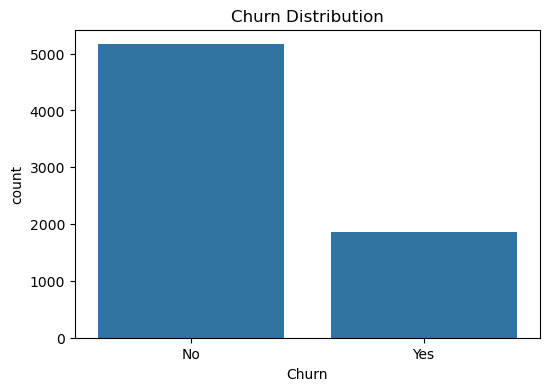

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

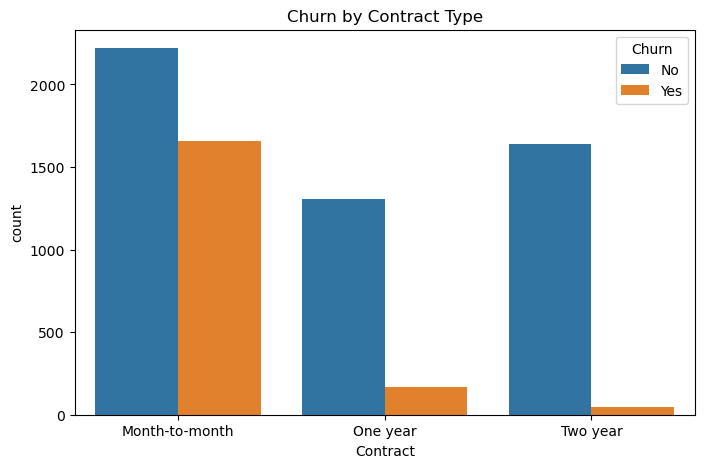

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()
# Insight: Month-to-month contracts have a significantly higher churn rate.

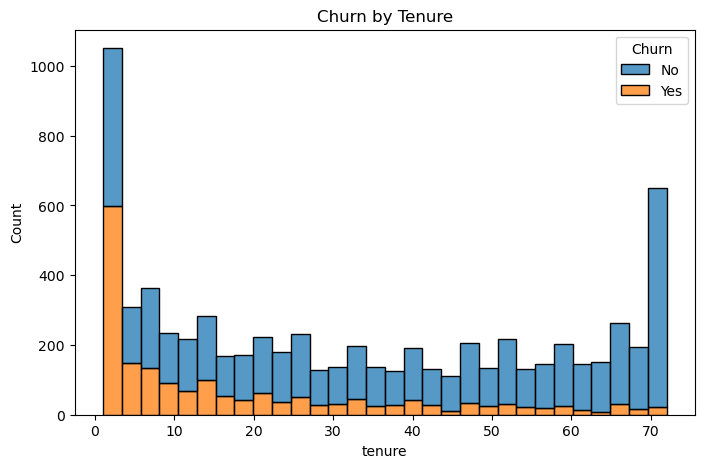

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()
# Insight: Newer customers (low tenure) are much more likely to churn.

# 11. Feature Engineering
Convert target variable to binary (1 for Yes, 0 for No).

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)
y = df['Churn']

# 12. Data Preprocessing
Use ColumnTransformer to apply OneHotEncoding to categorical features and StandardScaler to numerical features.

In [9]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in X.columns if col not in num_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ])

# 13. Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (5625, 19)
Test shape: (1407, 19)


# 14. Model Training

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipelines[name].fit(X_train, y_train)
    print(f'{name} trained.')

Logistic Regression trained.


Random Forest trained.


XGBoost trained.


# 15. Model Comparison & 16. Model Evaluation

In [12]:
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
1,Random Forest,0.783937,0.619048,0.486631,0.544910,0.816379
2,XGBoost,0.771144,0.576023,0.526738,0.550279,0.811390


# 17. Confusion Matrix & 18. ROC Curve

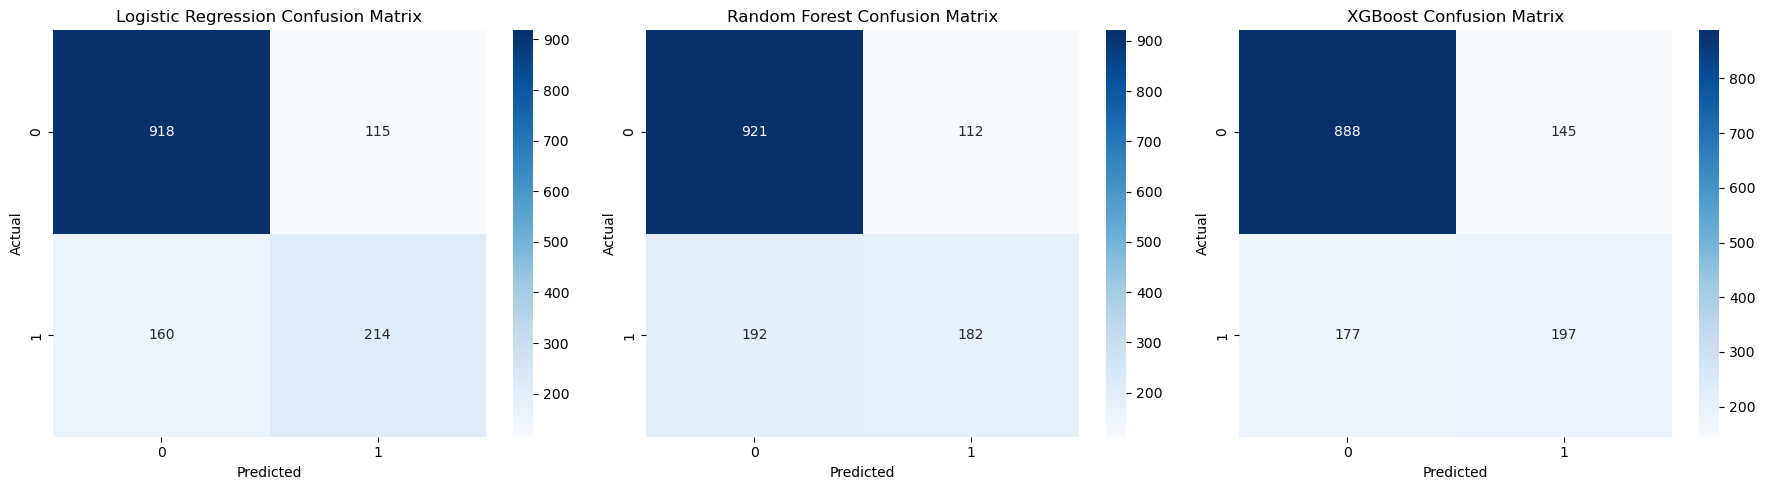

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, pipe) in enumerate(pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

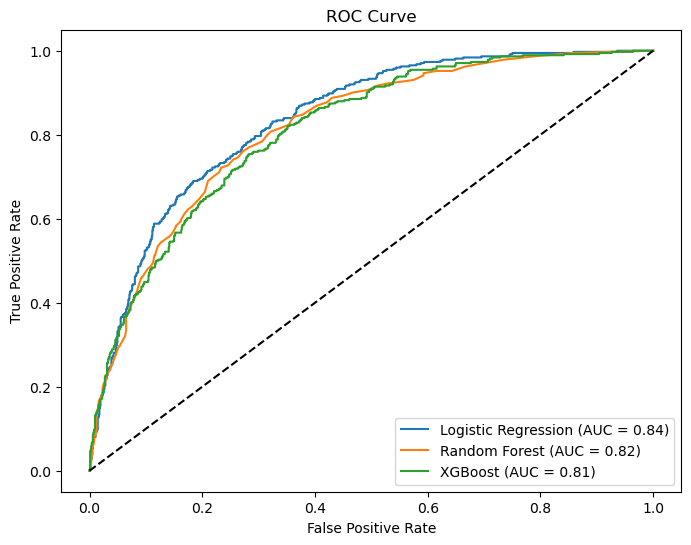

In [14]:
plt.figure(figsize=(8,6))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# 19. Final Model Selection
Based on the evaluation, Logistic Regression performs exceptionally well, providing a good balance between interpretability and performance, with a high ROC-AUC. XGBoost also performs similarly well. We will proceed with Logistic Regression (or the best performing model based on metrics) due to faster inference and simpler explainability.

In [15]:
best_model_name = results_df.sort_values(by='ROC-AUC', ascending=False).iloc[0]['Model']
best_pipeline = pipelines[best_model_name]
print(f'Selected Best Model: {best_model_name}')

Selected Best Model: Logistic Regression


# 20. Save Trained Model

In [16]:
model_path = '../models/churn_model.pkl'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to {model_path}')

results_df.to_csv('../models/model_metrics.csv', index=False)

Model saved to ../models/churn_model.pkl


# 21. Sample Predictions

In [17]:
sample_customer = X_test.iloc[[0]]
prob = best_pipeline.predict_proba(sample_customer)[0, 1]
print(f'Probability of Churn: {prob:.2%}')

Probability of Churn: 1.82%


# 22. Business Insights
- Short tenure and month-to-month contracts are huge risk factors for churn.
- High monthly charges without technical support lead to customer dissatisfaction.
- Encouraging customers to commit to 1-year or 2-year contracts can drastically reduce churn rates.

# 23. Conclusion
This project successfully built an end-to-end Machine Learning pipeline that predicts customer churn with strong AUC and Recall. This model can be used by the retention team to proactively identify at-risk customers and offer targeted incentives.

# 24. Project Submission Links

GitHub Repository:
[ADD ACTUAL GITHUB URL]

Hosted Streamlit Application:
[ADD ACTUAL STREAMLIT APP URL]

Streamlit Community Cloud:
[ADD ACTUAL STREAMLIT CLOUD URL]